# 03 · Results and the next decision

**Decision:** Keep feature engineering open until the four-policy evidence supports a frozen candidate and a documented stopping rationale. This is a research prototype with strong experimental infrastructure; independent confirmation and a deployed final representation remain unfinished.

This short notebook is the employer review path. It separates measured development results from the claims the project can responsibly make.

In [1]:
import os
from pathlib import Path
import pandas as pd
from IPython.display import display
from jigsaw_rules.review import public_evidence
from jigsaw_rules.runtime import environment

root = Path(os.environ.get("JIGSAW_ROOT", Path.cwd())).resolve()
if root.name == "notebooks":
    root = root.parent
baseline = public_evidence(root, "baseline")
semantic = public_evidence(root, "semantic")
assert baseline["training_sha256"] == semantic["training_sha256"]
print("Historical references: 2,029 rows, two policies; expanded research is a separate cohort.")
print("Aggregate checksums verified. This notebook performs no model fitting.")
protocols = {"seen_rule": "Familiar rules", "heldout_rule": "Held-out rule"}

def metric_table(records, heldout=False):
    return pd.DataFrame([{"Representation": r["model"], "Validation": protocols[r["protocol"]],
        "Rule macro AUC": r["metrics"]["rule_macro_auc"],
        "Log loss": r["metrics"]["log_loss"], "Brier": r["metrics"]["brier"],
        "Average precision": r["metrics"]["average_precision"]}
        for r in records if not heldout or r["protocol"] == "heldout_rule"]).round(4)


Historical references: 2,029 rows, two policies; expanded research is a separate cohort.
Aggregate checksums verified. This notebook performs no model fitting.


In [2]:
import sys
sys.path.insert(0, str(root / "scripts"))
from build_research_report import display_figure
from build_release_report import display_boundary
from jigsaw_rules.features import feature_evidence
from jigsaw_rules.research import research_evidence
from jigsaw_rules.diagnostics import diagnostic_evidence
from jigsaw_rules.pairs import pairs_evidence
from jigsaw_rules.robustness import robustness_evidence
from jigsaw_rules.gate import feature_gate
from jigsaw_rules.instructions import instruction_evidence
from jigsaw_rules.released import released_evidence
from jigsaw_rules.expanded import expanded_evidence
from jigsaw_rules.retrieval import retrieval_evidence
from jigsaw_rules.resolution import resolution_evidence
from build_expanded_report import display_figure as display_expanded

expanded = expanded_evidence(root)
retrieval = retrieval_evidence(root)
resolution = resolution_evidence(root)
assert expanded is not None and retrieval is not None and resolution is not None
controls = feature_evidence(root)
research = research_evidence(root)
sensitivity = diagnostic_evidence(root)
pairs = pairs_evidence(root)
robustness = robustness_evidence(root)
assert all(item is not None for item in (controls, research, sensitivity, pairs, robustness))
gate = feature_gate(root)
instructions = instruction_evidence(root)
released = released_evidence(root)
assert released is not None
print("Verified expanded study:", expanded["metadata"]["run_id"])


Verified expanded study: a57bb74350fcbcd66592


## What the expanded research measured
Thirty-four fixed trained configurations share seven purged splits. The feature study adds/removes major families, checks full versus screened representations, and tests training-only NB/SVD controls. Frozen semantic scores are untrained comparison baselines. The 43,576-row reserve remains outside model selection.

The frozen semantic centroid reaches **0.7042 transfer AUC**, versus **0.4728** for the matched lexical reference. Its log loss improves from 0.8126 to 0.6237. Most of the gain comes from avoiding reversed lexical ranking on illegal-activity promotion; legal and medical advice remain difficult. The all-transfer model reaches 0.7989 on familiar policies but only 0.5515 on transfer.

Policy-macro AUC is the primary competition-oriented metric. These are post-competition development results, not a Kaggle score.

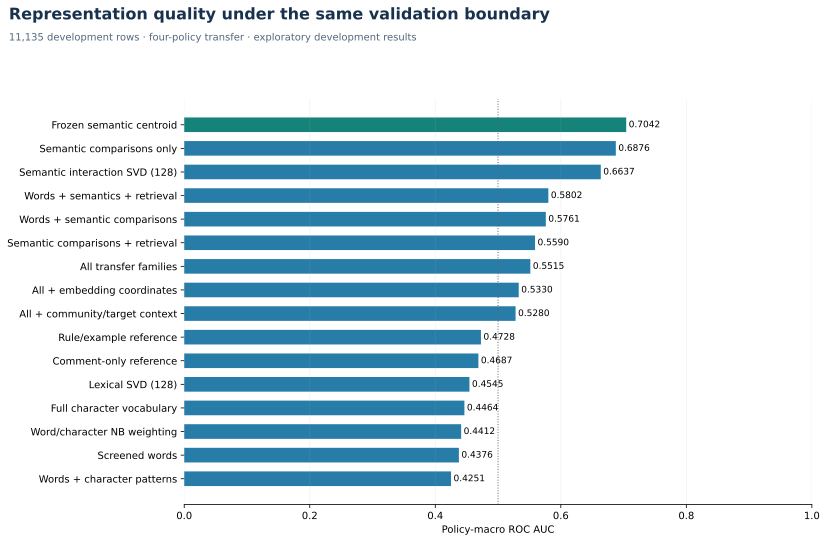

,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
14,qwen_centroid,Held-out rule,0.7042,0.6237,0.2177,0.7559
17,qwen_kernel_0.2,Held-out rule,0.6935,0.6617,0.2347,0.6928
18,qwen_kernel_0.5,Held-out rule,0.6933,0.6775,0.2422,0.6884
16,qwen_kernel_0.1,Held-out rule,0.6929,0.6558,0.2321,0.6977
20,qwen_mean,Held-out rule,0.6928,0.6628,0.2353,0.6848
15,qwen_kernel_0.05,Held-out rule,0.6908,0.7090,0.2469,0.7023
24,semantic_scalar_only,Held-out rule,0.6876,0.6891,0.2456,0.6872
19,qwen_maximum,Held-out rule,0.6850,0.6513,0.2300,0.7086
12,latent_qwen_interaction,Held-out rule,0.6637,0.7939,0.2883,0.5613
25,without_character,Held-out rule,0.5910,1.4643,0.4560,0.5050


In [3]:
display_expanded(root, "comparison")
summary = metric_table(expanded["results"] + retrieval["results"], heldout=True).sort_values("Rule macro AUC", ascending=False)
display(summary.head(10))

## What would count as a feature improvement?
The family-ablation figure in notebook `02` measures additions to the same screened-word control. The table below compares each representation with the same-fold rule/example reference. A higher point estimate with an interval crossing zero remains an uncertain development observation. Probability losses and policy-level failures are part of the decision. Simultaneous intervals apply within each preregistered study; combining rows below does not create one joint correction over all research.

In [4]:
contrasts = pd.DataFrame(expanded["uncertainty"] + retrieval["uncertainty"])
compared = contrasts[(contrasts.protocol == "heldout_rule") & (contrasts.reference == "rule_examples")]
display(compared.sort_values("observed_delta", ascending=False).head(10)[["candidate", "observed_delta", "ci_lower", "ci_upper", "simultaneous_lower", "simultaneous_upper"]].round(4))

,candidate,observed_delta,ci_lower,ci_upper,simultaneous_lower,simultaneous_upper
73,qwen_centroid,0.2314,0.1985,0.2600,0.1889,0.2740
76,qwen_kernel_0.2,0.2208,0.1879,0.2488,0.1782,0.2633
77,qwen_kernel_0.5,0.2206,0.1875,0.2487,0.1780,0.2631
75,qwen_kernel_0.1,0.2202,0.1872,0.2484,0.1776,0.2627
79,qwen_mean,0.2200,0.1867,0.2481,0.1775,0.2626
74,qwen_kernel_0.05,0.2180,0.1846,0.2456,0.1755,0.2606
82,semantic_scalar_only,0.2149,0.1802,0.2428,0.1723,0.2574
78,qwen_maximum,0.2122,0.1789,0.2404,0.1696,0.2547
71,latent_qwen_interaction,0.1909,0.1527,0.2222,0.1484,0.2335
83,without_character,0.1183,0.0835,0.1532,0.0757,0.1608


## Why this remains an open product decision
The research loader never exposes reserved targets. The public reports are checksummed summaries of verified private OOF predictions. The standalone inference notebook still uses the named lexical reference; no research candidate is silently presented as the production model.

The next acceptance milestone is a defensible feature stopping decision, followed by one locked confirmation comparison. Then the accepted representation needs calibrated/triage diagnostics, offline feature parity, latency and memory measurements, and an example-driven demonstration with a model card. Passing software tests does not substitute for those deliverables.

In [5]:
print("Expanded study:", gate["expanded_development"])
print("Feature gate:", gate["status"])
print("Final training justified:", gate["final_training_authorized_by_evidence"])

Expanded study: {'rows': 11135, 'policies': 4, 'fitted_models': 260}
Feature gate: open
Final training justified: False


## Explore the reasoning
[02 · Research methods, screening and ablations](02_baseline_and_review.ipynb) · [04 · Per-policy and probability diagnostics](04_semantic_benchmark.ipynb) · [01 · Leakage boundaries](01_data_and_validation.ipynb) · [Remaining release milestones](../docs/ROADMAP.md).

The historical two-policy search is preserved in the [research record](../docs/FEATURE_RESEARCH.md); its scores are not compared numerically with this larger cohort as if only the features had changed.